# Modelowanie Matematyczne - Projekt
## Teoria obrazów
### Paweł Drzyzga, nr albumu: 143200,
#### pawel.drzyzga@student.pk.edu.pl
#### Matematyka Stosowana 2 stopień, 1 rok

In [39]:
import numpy as np
import imageio.v3 as iio

from skimage import exposure, filters, morphology, measure, segmentation
from scipy import ndimage as ndi

from pathlib import Path
import matplotlib.pyplot as plt
from skimage import measure, segmentation
import imageio.v3 as iio
from io import BytesIO

import argparse
import math

import pandas as pd

import plotly.graph_objects as go

### I/O + ROI (Region of Interest)

Ten blok wczytuje obraz w skali szarości i ogranicza go do górnej części
$0 \le y < y_{\max}$, czyli wycina obszar zainteresowania używany
w dalszej analizie. Chroni też pipeline przed podaniem obrazu RGB.

In [40]:
# ---------- I/O + ROI ----------
def load_and_crop(path, y_max=2060):
    img = iio.imread(path)
    if img.ndim != 2:
        raise ValueError("Oczekuję obrazu 2D (grayscale).")
    return img[:y_max, :]

### Preprocess

Normalizacja obrazu do zakresu $[0,1]$, opcjonalne wzmocnienie lokalnego kontrastu (CLAHE)
oraz lekkie odszumianie filtrem Gaussa o szerokości $\sigma$.
Ten etap stabilizuje dalsze algorytmy detekcji i analizy struktury.


In [41]:
# ---------- Preprocess ----------
def preprocess(img, use_clahe=False, sigma=1.0):
    x = img.astype(np.float32)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)  # [0,1]

    # HAADF zwykle ma OK kontrast; CLAHE czasem dodaje artefakty – daję domyślnie False
    if use_clahe:
        x = exposure.equalize_adapthist(x, clip_limit=0.01)

    # lekkie odszumianie
    x = filters.gaussian(x, sigma=sigma, preserve_range=True)
    return x


### Segmentacja jasnych obiektów

Ten etap wykrywa i rozdziela jasne struktury w obrazie:
najpierw przez globalne progowanie (Otsu), potem przez czyszczenie morfologiczne,
a opcjonalnie przez watershed oparty na transformacie odległości,
aby rozdzielać stykające się obiekty.
Zwracane są kolejne etapy masek i finalne etykiety obiektów.

In [42]:
# ---------- Segmentacja: JASNE OBIEKTY ----------
def segment_bright_objects_steps(x, min_size=80, min_hole=60, use_watershed=True):
    # 1) próg
    t = filters.threshold_otsu(x)
    mask_raw = x > t

    # 2) czyszczenie
    mask_clean = morphology.remove_small_objects(mask_raw, min_size=min_size)
    mask_clean = morphology.remove_small_holes(mask_clean, area_threshold=min_hole)

    labels_ws = None

    # 3) watershed (opcjonalnie)
    if use_watershed:
        dist = ndi.distance_transform_edt(mask_clean)
        peaks = morphology.local_maxima(dist)
        markers = measure.label(peaks)
        labels_ws = segmentation.watershed(-dist, markers, mask=mask_clean)
        mask_after = labels_ws > 0
    else:
        mask_after = mask_clean

    # 4) finalne etykiety
    labels_final = measure.label(mask_after)

    return mask_raw, mask_clean, labels_ws, labels_final

### Dyski ekwiwalentne

Każdy wykryty obiekt binarny jest aproksymowany przez dysk o tym samym polu
($r = \sqrt{A/\pi}$), którego środek jest rzutowany do jednostkowej komórki
$(-\tfrac12,\tfrac12)^2$ i zapisywany jako liczba zespolona.
Taka reprezentacja upraszcza późniejszą analizę geometryczną i okresową.

In [43]:
# ---------- Dyski ekwiwalentne ----------
def disks_from_labels(labels):
    props = measure.regionprops(labels)
    H, W = labels.shape

    disks = []
    for p in props:
        cy, cx = p.centroid  # (row, col)
        r_px = np.sqrt(p.area / np.pi)

        # do komórki jednostkowej (-1/2, 1/2)^2
        ax = (cx / W) - 0.5
        ay = (cy / H) - 0.5
        a = ax + 1j * ay

        r_norm = r_px / W
        disks.append((a, r_norm, cx, cy, r_px))

    return disks

### Eksport dysków do CSV

Zapisuje parametry dysków (pozycja zespolona, promień znormalizowany oraz
współrzędne w pikselach) do pliku CSV, aby można je było dalej analizować
lub używać w zewnętrznych narzędziach i skryptach.

In [44]:
# ---------- CSV ----------
def save_disks_csv(disks, out_csv):
    import csv
    with open(out_csv, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["a_re", "a_im", "r_norm", "cx_px", "cy_px", "r_px"])
        for a, r_norm, cx, cy, r_px in disks:
            w.writerow([a.real, a.imag, r_norm, cx, cy, r_px])

### Podgląd centroidów

Rysuje obraz źródłowy i nakłada na niego pozycje środków wykrytych dysków,
co pozwala szybko wizualnie zweryfikować poprawność segmentacji i lokalizacji obiektów.

In [45]:
# ---------- Overlay ----------
def overlay_preview(img, disks, title="Centroidy"):
    import matplotlib.pyplot as plt
    plt.figure()
    plt.imshow(img, cmap="gray")
    xs = [d[2] for d in disks]
    ys = [d[3] for d in disks]
    plt.scatter(xs, ys, s=10)
    plt.title(f"{title} (N={len(disks)})")
    plt.axis("off")
    plt.show()

### Zapis obrazu pomocniczego

Zapisuje dowolną macierz 2D jako obraz w skali szarości do pliku,
używane do archiwizacji pośrednich wyników (maski, mapy odległości, etapy segmentacji).

In [46]:
def _save_gray(path, arr, title=None):
    plt.figure()
    plt.imshow(arr, cmap="gray")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

### Eksport etapów segmentacji

Ten fragment zapisuje do katalogu kolejne etapy przetwarzania:
oryginał, obraz po preprocessingu, maski binarne oraz wizualizacje konturów
i granic etykiet na tle obrazu. Służy to do audytu jakości segmentacji
i debugowania całego pipeline’u.

In [47]:
def save_segmentation_steps(out_dir, img, x, mask_raw, mask_clean, labels_final):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    _save_gray(out_dir / "01_original.png", img, "1) Oryginał")
    _save_gray(out_dir / "02_preprocess.png", x, "2) Po preprocess")
    _save_gray(out_dir / "03_mask_raw.png", mask_raw.astype(np.uint8)*255, "3) Maska po progu (raw)")
    _save_gray(out_dir / "04_mask_clean.png", mask_clean.astype(np.uint8)*255, "4) Maska po czyszczeniu")

    # kontury maski na oryginale
    contours = measure.find_contours(mask_clean.astype(float), 0.5)
    plt.figure()
    plt.imshow(img, cmap="gray")
    for c in contours:
        plt.plot(c[:, 1], c[:, 0], linewidth=1)
    plt.title("5) Kontury maski na oryginale")
    plt.axis("off")
    plt.savefig(out_dir / "05_contours_overlay.png", dpi=200, bbox_inches="tight")
    plt.close()

    # granice etykiet na oryginale
    boundaries = segmentation.find_boundaries(labels_final, mode="outer")
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.imshow(boundaries.astype(float), alpha=0.7)
    plt.title("6) Granice etykiet na oryginale")
    plt.axis("off")
    plt.savefig(out_dir / "06_label_boundaries.png", dpi=200, bbox_inches="tight")
    plt.close()

### Konwersja wykresu do obrazu

Zamienia obiekt `matplotlib.figure.Figure` na tablicę RGB w pamięci,
bez zapisu na dysk, co umożliwia dalsze przetwarzanie lub składanie wizualizacji
w ramach pipeline’u.

In [48]:
def _fig_to_rgb_array(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return iio.imread(buf.getvalue())

### Animacja etapów segmentacji (GIF)

Tworzy animowany podgląd kolejnych kroków pipeline’u:
od obrazu wejściowego, przez maski binarne, aż do granic etykiet.
Ułatwia to szybkie porównanie etapów i ocenę, gdzie segmentacja działa
dobrze, a gdzie wprowadza błędy.

In [49]:
def make_segmentation_gif(out_gif, img, x, mask_raw, mask_clean, labels_final, duration=0.9):
    frames = []

    def add_frame(title, base, overlay=None, overlay_alpha=0.35, contours=None):
        fig = plt.figure()
        plt.imshow(base, cmap="gray")
        if overlay is not None:
            plt.imshow(overlay, alpha=overlay_alpha)
        if contours is not None:
            for c in contours:
                plt.plot(c[:, 1], c[:, 0], linewidth=1)
        plt.title(title)
        plt.axis("off")
        frames.append(_fig_to_rgb_array(fig))

    add_frame("1) Oryginał", img)
    add_frame("2) Po preprocess", x)
    add_frame("3) Maska po progu", img, overlay=mask_raw.astype(float))
    add_frame("4) Maska po czyszczeniu", img, overlay=mask_clean.astype(float))

    contours = measure.find_contours(mask_clean.astype(float), 0.5)
    add_frame("5) Kontury maski", img, contours=contours)

    boundaries = segmentation.find_boundaries(labels_final, mode="outer").astype(float)
    add_frame("6) Granice etykiet", img, overlay=boundaries, overlay_alpha=0.7)

    out_gif = Path(out_gif)
    out_gif.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(out_gif, frames, duration=duration, loop=0)

### Animacja narastających etykiet

Pokazuje, jak kolejne obiekty (etykiety segmentacji) są stopniowo
dodawane na tle obrazu źródłowego. Taki widok pozwala ocenić
rozmieszczenie, gęstość i kolejność wykrytych struktur.

In [50]:
def make_growing_labels_gif(out_gif, img, labels_final, step=3, duration=0.12):
    frames = []
    max_lab = int(labels_final.max())
    current = np.zeros_like(labels_final, dtype=bool)

    for k in range(1, max_lab + 1, step):
        for j in range(k, min(k + step, max_lab + 1)):
            current |= (labels_final == j)

        fig = plt.figure()
        plt.imshow(img, cmap="gray")
        plt.imshow(current.astype(float), alpha=0.35)
        plt.title(f"Narastająco: etykiety ≤ {min(k+step-1, max_lab)} / {max_lab}")
        plt.axis("off")
        frames.append(_fig_to_rgb_array(fig))

    out_gif = Path(out_gif)
    out_gif.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(out_gif, frames, duration=duration, loop=0)


### Uruchomienie pełnego pipeline’u

Ten fragment wykonuje cały przepływ obliczeń dla pojedynczego obrazu:
od wczytania i preprocessingu, przez segmentację jasnych obiektów,
aż po ekstrakcję dysków, zapis do CSV oraz wygenerowanie wizualizacji
kontrolnych (obrazy i animacje GIF).
Służy jako punkt wejścia do analizy danych HAADF.

In [ ]:
if __name__ == "__main__":
    path = r"15.47.34 Scanning Acquire-2-Acquire HAADF.tif"

    img = load_and_crop(path, y_max=2060)
    x = preprocess(img, use_clahe=True, sigma=1.0)

    mask_raw, mask_clean, labels_ws, labels_final = segment_bright_objects_steps(
        x,
        min_size=20,
        min_hole=30,
        use_watershed=True
    )

    disks = disks_from_labels(labels_final)

    print("N_disks:", len(disks))
    save_disks_csv(disks, "haadf_disks_bright.csv")
    overlay_preview(img, disks, title="HAADF – jasne obiekty")

    # --- DEBUG / wizualizacje kroków ---
    out_dir = "debug_steps_haadf"
    save_segmentation_steps(out_dir, img, x, mask_raw, mask_clean, labels_final)
    make_segmentation_gif(f"{out_dir}/segmentation_steps.gif", img, x, mask_raw, mask_clean, labels_final, duration=0.9)
    make_growing_labels_gif(f"{out_dir}/growing_labels.gif", img, labels_final, step=3, duration=0.12)

    print(f"Zapisano obrazki i GIF-y do folderu: {out_dir}")

### Krata kwadratowa w $\mathbb{C}$

Ten blok generuje punkty dwuwymiarowej kraty zespolonej
$$
\Lambda = \{\, \omega = m + i n \mid m,n \in \mathbb{Z},\ |m|\le M,\ |n|\le M \,\},
$$
czyli dyskretny wycinek standardowej kraty $\mathbb{Z}^2 \subset \mathbb{C}$.
Punkty te służą jako wektory przesunięć w sumach strukturalnych
i w funkcjach okresowych (np. eliptycznych).


In [52]:
def _lattice_points_square(M: int) -> np.ndarray:
    """
    Punkty kraty: ω = m + i n dla |m|,|n|<=M.
    Zwraca tablicę complex128, zawiera ω=0.
    """
    shifts = range(-M, M + 1)
    pts = []
    for m in shifts:
        for n in shifts:
            pts.append(1 * m + 1j * n)
    return np.array(pts, dtype=np.complex128)

### Stała kratowa $S_2$ dla kraty kwadratowej

Ta funkcja liczy obciętą wersję sumy kratowej
$$
S_2 \;=\; \sum_{\omega \in \Lambda \setminus \{0\}} \frac{1}{\omega^2},
\qquad 
\Lambda = \{ m + i n \mid m,n \in \mathbb{Z} \},
$$
gdzie w implementacji suma jest liczona symetrycznie dla
$|m|,|n|\le M$.

Jest to suma **warunkowo zbieżna**, więc sposób obcinania (tu: pudełko kratowe)
ma znaczenie i odpowiada naturalnej symetrii kraty kwadratowej używanej
w dalszych wzorach funkcji eliptycznych.

W późniejszej wersji, jednak dla uproszczenia korzystamy z $$ S_2 = \pi $$

In [53]:
def lattice_S2_square(M: int) -> complex:
    r"""
    S2 = sum_{ω≠0} 1/ω^2

    UWAGA: to suma warunkowo zbieżna. Tutaj liczona symetrycznie w pudełku
    |m|,|n|<=M, co odpowiada „naturalnemu” obcięciu w Twoim podejściu.
    """
    pts = _lattice_points_square(M)
    pts = pts[pts != 0]
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        s2 = np.sum(1.0 / (pts ** 2))
    return complex(s2)

### Funkcja Weierstrassa $\wp(z)$ dla kraty kwadratowej

Ten blok implementuje uciętą postać funkcji eliptycznej Weierstrassa
dla półokresów $\omega_1=1$, $\omega_2=i$:
$$
\wp(z)
=
\frac{1}{z^2}
+
\sum_{\omega\in\Lambda\setminus\{0\}}
\left(
\frac{1}{(z+\omega)^2}
-
\frac{1}{\omega^2}
\right),
\qquad
\Lambda=\{m+in:\,m,n\in\mathbb Z\}.
$$

Człon $-\tfrac{1}{\omega^2}$ regularizuje sumę, dzięki czemu jest ona
absolutnie zbieżna i może być stabilnie liczona przez obcięcie
$|m|,|n|\le M$ w implementacji.


In [54]:
# ============================================================
# Weierstrass ℘ i jej pochodne (krata kwadratowa)
# ============================================================

def weierstrass_p_square(Z: np.ndarray, M: int = 12) -> np.ndarray:
    r"""
    Weierstrass ℘ dla kraty kwadratowej (ω1=1, ω2=i) w wersji uciętej:

      ℘(z) = 1/z^2 + Σ_{ω≠0} [ 1/(z+ω)^2 - 1/ω^2 ]

    Człon -1/ω^2 regularizuje sumę i daje zbieżność absolutną.
    """
    Z = np.asarray(Z, dtype=np.complex128)
    wp = np.zeros_like(Z, dtype=np.complex128)

    pts = _lattice_points_square(M)
    pts_nz = pts[pts != 0]

    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        wp += 1.0 / (Z ** 2)
        for w in pts_nz:
            wp += 1.0 / ((Z + w) ** 2) - 1.0 / (w ** 2)

    return wp

### Pochodne funkcji Weierstrassa $\wp^{(k)}(z)$

Ten blok oblicza $k$-tą pochodną funkcji Weierstrassa dla kraty kwadratowej,
korzystając z bezpośredniej postaci sumy kratowej:
$$
\wp^{(k)}(z)
=
(-1)^k (k+1)!
\sum_{\omega\in\Lambda}
\frac{1}{(z+\omega)^{k+2}},
\qquad k\ge 1,
$$
gdzie
$$
\Lambda=\{m+in:\; m,n\in\mathbb Z\}.
$$

Dla $k\ge 1$ suma jest absolutnie zbieżna i nie wymaga regularizacji,
natomiast przypadek $k=0$ (sama $\wp$) jest obsługiwany osobno
przez wzór z odjęciem $1/\omega^2$.


In [55]:
def weierstrass_p_derivative_square(Z: np.ndarray, k: int, M: int = 12) -> np.ndarray:
    r"""
    k-ta pochodna ℘ po z (k>=1) dla kraty kwadratowej.

    Korzystamy z tożsamości (dla k>=1 suma jest absolutnie zbieżna):
      ℘^{(k)}(z) = (-1)^k (k+1)! Σ_{ω∈Λ} 1/(z+ω)^{k+2}

    Dla k=0 (sama ℘) używamy regularizacji w weierstrass_p_square().
    """
    if k < 0:
        raise ValueError("k musi być >= 0")
    if k == 0:
        return weierstrass_p_square(Z, M=M)

    Z = np.asarray(Z, dtype=np.complex128)
    out = np.zeros_like(Z, dtype=np.complex128)

    pts = _lattice_points_square(M)  # zawiera ω=0

    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        for w in pts:
            out += 1.0 / ((Z + w) ** (k + 2))

    out *= ((-1) ** k) * math.factorial(k + 1)
    return out


### Funkcje Eisensteina $E_m(z)$ dla kraty kwadratowej

Ten blok definiuje funkcje Eisensteina używane w cechach strukturalnych,
wprost przez funkcję Weierstrassa i jej pochodne:
$$
E_2(z) = \wp(z) + S_2,
$$
$$
E_m(z) = \frac{(-1)^m}{(m-1)!}\,\frac{d^{\,m-2}}{dz^{\,m-2}}\wp(z),
\qquad m\ge 3,
$$
gdzie
$$
% S_2=\sum_{\omega\in\Lambda\setminus\{0\}}\frac{1}{\omega^2}, 
% \qquad
% \Lambda=\{m+in:\;m,n\in\mathbb Z\}.
S_2 = \pi
$$

Przypadek $E_1$ jest pominięty, ponieważ jest warunkowo zbieżny
i nie jest potrzebny do budowy cech w dalszej analizie.

In [56]:
def E_m_square_from_weierstrass(
    Z: np.ndarray,
    m: int,
    M: int = 12,
    S2_cache: complex | None = None
) -> np.ndarray:
    r"""
    Funkcje Eisensteina zgodne ze screenem:

      E2(z) = ℘(z) + S2
      Em(z) = (-1)^m/(m-1)! * d^{m-2}℘(z)/dz^{m-2}    dla m>=3

    E1 pomijamy (warunkowo zbieżna i niepotrzebna do Twoich cech).
    """
    if m == 2:
        wp = weierstrass_p_square(Z, M=M)
        s2 = S2_cache if S2_cache is not None else lattice_S2_square(M)
        return wp + s2

    if m >= 3:
        k = m - 2
        wp_k = weierstrass_p_derivative_square(Z, k=k, M=M)  # ℘^{(m-2)}
        coef = ((-1) ** m) / math.factorial(m - 1)
        return coef * wp_k

    raise ValueError("Obsługiwane są m=2 oraz m>=3 (E1 pominięte).")

### Diagnostyka odległości między punktami

Ten fragment oblicza statystyki parowych odległości
$$
d_{ij} = |a_i - a_j|,
\qquad i\ne j,
$$
między centrami dysków zapisanymi jako liczby zespolone.
Zwracane są minimalna odległość oraz wybrane percentyle,
co pozwala ocenić gęstość i możliwe kolizje punktów w układzie.


In [57]:
# ============================================================
# Diagnostyka odległości
# ============================================================

def distance_diagnostics(a: np.ndarray) -> dict:
    """
    Minimalna odległość oraz percentyle odległości |a_i-a_j| (bez przekątnej).
    """
    Z = a[:, None] - a[None, :]
    np.fill_diagonal(Z, np.nan + 1j * np.nan)
    d = np.abs(Z)
    return {
        "dist_min": float(np.nanmin(d)),
        "dist_p1": float(np.nanpercentile(d, 1)),
        "dist_p5": float(np.nanpercentile(d, 5)),
        "dist_p10": float(np.nanpercentile(d, 10)),
    }


### Wczytanie dysków z CSV

Ten blok rekonstruuje pozycje i promienie dysków z pliku CSV,
tworząc wektor liczb zespolonych
$$
a_i = a_i^{(\mathrm{re})} + i\,a_i^{(\mathrm{im})}
$$
oraz odpowiadający mu wektor promieni $r_i$,
które są dalej używane w sumach strukturalnych.


In [58]:
# ============================================================
# CSV -> a,r
# ============================================================

def load_disks_csv(csv_path: Path) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path)

    required = {"a_re", "a_im", "r_norm"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Brak kolumn w CSV: {sorted(missing)}")

    a = df["a_re"].to_numpy(dtype=float) + 1j * df["a_im"].to_numpy(dtype=float)
    r = df["r_norm"].to_numpy(dtype=float)
    return a.astype(np.complex128), r.astype(float)

### Suma strukturalna $e_2$ i jej wersja ważona

Ten blok oblicza klasyczną oraz ważoną wersję sumy strukturalnej drugiego rzędu,
opartej na funkcji Eisensteina $E_2(z)$.

Najpierw definiujemy różnice położeń:
$$
z_{ij} = a_i - a_j,\qquad i\ne j,
$$
gdzie $a_i\in\mathbb C$ są środkami dysków.

Funkcja Eisensteina drugiego rzędu ma postać
$$
E_2(z)=\wp(z)+S_2,
\qquad
S_2=\pi.
$$

Klasyczna suma strukturalna:
$$
e_2
=
\frac{1}{N^2}
\sum_{i=1}^N
\sum_{j=1}^N
E_2(z_{ij}).
$$

Każdemu dyskowi przypisujemy wagę równą jego polu:
$$
w_i=\pi r_i^2,\qquad
f=\sum_{i=1}^N w_i.
$$

Wersja ważona:
$$
e_2^{\mathrm{mod}}
=
\frac{1}{f^2}
\sum_{i=1}^N
\sum_{j=1}^N
w_i w_j \, E_2(z_{ij}).
$$

W implementacji przekątna $i=j$ oraz wartości osobliwe są zerowane,
aby uniknąć wpływu nieskończoności $\wp(0)$ na sumy.


In [59]:
# ============================================================
# e2, e2_mod
# ============================================================

def compute_e2_and_e2mod(a: np.ndarray, r: np.ndarray, M: int = 12) -> dict:
    N = len(a)
    if N < 2:
        raise ValueError("Za mało obiektów (N < 2).")

    # różnice położeń
    Z = a[:, None] - a[None, :]
    np.fill_diagonal(Z, np.nan + 1j * np.nan)

    # E2(z) = wp(z) + S2
    S2 = lattice_S2_square(M)
    E2 = E_m_square_from_weierstrass(Z, m=2, M=M, S2_cache=S2)

    # porządkowanie: wyzeruj NaN/inf i przekątną
    E2 = np.where(np.isfinite(E2.real), E2, 0.0 + 0.0j)
    np.fill_diagonal(E2, 0.0 + 0.0j)

    # klasyczne e2
    e2 = E2.sum() / (N * N)

    # wagi i f
    w = np.pi * r**2
    f = w.sum()

    # wersja ważona
    W = w[:, None] * w[None, :]
    np.fill_diagonal(W, 0.0)

    e2_mod = (W * E2).sum() / (f**2)

    return {
        "N": int(N),
        "M": int(M),
        "f": float(f),
        "e2_re": float(e2.real),
        "e2_im": float(e2.imag),
        "e2_abs": float(abs(e2)),
        "e2_mod_re": float(e2_mod.real),
        "e2_mod_im": float(e2_mod.imag),
        "e2_mod_abs": float(abs(e2_mod)),
    }

### Ważona suma strukturalna $e^{\mathrm{mod}}_{p,p}$

Ten fragment implementuje ważoną sumę strukturalną rzędu $(p,p)$
opartą na funkcjach Eisensteina $E_p$.

Dla centrów $a_i\in\mathbb C$ i promieni $r_i$ definiujemy wagi
$$
w_i=\pi r_i^2,\qquad
f=\sum_{i=1}^N w_i,
$$
oraz różnice
$$
z_{ij}=a_i-a_j.
$$

Niech
$$
E_p(z)=
\begin{cases}
\wp(z)+S_2, & p=2,\\[4pt]
\dfrac{(-1)^p}{(p-1)!}\,\dfrac{d^{p-2}}{dz^{p-2}}\wp(z), & p\ge 3.
\end{cases}
$$

Definiujemy pomocnicze sumy:
$$
u_j=\sum_{i=1}^N w_i\,E_p(z_{ij}),\qquad
v_j=\sum_{k=1}^N w_k\,\overline{E_p(z_{jk})}.
$$

Wtedy ważona suma strukturalna ma postać:
$$
e^{\mathrm{mod}}_{p,p}
=
\frac{1}{f^{\,p+1}}
\sum_{j=1}^N
w_j^{\,p-1}\,u_j\,v_j.
$$

Tak jak w kodzie, składniki z $i=j$ są wyzerowane,
aby usunąć osobliwości funkcji $\wp(0)$.


In [60]:
# ============================================================
# e_{p,p}^{mod}
# ============================================================

def compute_epp_mod(a: np.ndarray, r: np.ndarray, p: int, M: int = 12) -> dict:
    """
    e_{p,p}^{mod}:
      1/f^{p+1} * sum_j w_j^{p-1} * (sum_i w_i Ep(i,j)) * (sum_k w_k conj(Ep(j,k)))
    gdzie Ep = E_p(a_i-a_j).
    """
    if p < 2:
        raise ValueError("p musi być >= 2 (E1 pomijamy).")

    N = len(a)
    if N < 2:
        raise ValueError("Za mało obiektów (N < 2).")

    w = np.pi * r**2
    f = w.sum()

    Z = a[:, None] - a[None, :]
    np.fill_diagonal(Z, np.nan + 1j * np.nan)

    # Ep z Weierstrassa (dla p=2 używa wp+S2)
    S2 = lattice_S2_square(M) if p == 2 else None
    Ep = E_m_square_from_weierstrass(Z, m=p, M=M, S2_cache=S2)

    Ep = np.where(np.isfinite(Ep.real), Ep, 0.0 + 0.0j)
    np.fill_diagonal(Ep, 0.0 + 0.0j)

    u = (w[:, None] * Ep).sum(axis=0)               # po kolumnach (N,)
    v = (w[None, :] * np.conjugate(Ep)).sum(axis=1) # po wierszach  (N,)

    epp_mod = ((w**(p-1)) * u * v).sum() / (f**(p+1))

    return {
        "p": int(p),
        "epp_mod_re": float(epp_mod.real),
        "epp_mod_im": float(epp_mod.imag),
        "epp_mod_abs": float(abs(epp_mod)),
    }

In [3]:
pd.read_csv('haadf_disks_bright.csv')

,a_re,a_im,r_norm,cx_px,cy_px,r_px
0,-0.02747468,-0.46992090,0.04866003,967.73185897,61.96294872,99.65574970
1,0.14084556,-0.48569395,0.02221358,1312.45170717,29.47047062,45.49341579
2,0.23104816,-0.48310996,0.01842651,1497.18663388,34.79347340,37.73749370
3,0.45743547,-0.44926461,0.05145050,1960.82784324,104.51489350,105.37061801
4,-0.04095608,-0.49178309,0.00176395,940.12195122,16.92682927,3.61257600
...,...,...,...,...,...,...
84,0.20980980,0.41826167,0.00178534,1453.69047619,1891.61904762,3.65636640
85,0.20533854,0.42407228,0.00261346,1444.53333333,1903.58888889,5.35237235
86,0.24181112,0.46307649,0.04288611,1519.22917268,1983.93756963,87.83074685
87,0.46957982,0.47747097,0.02063367,1985.69946524,2013.59019608,42.25776214


In [2]:
pd.set_option('display.float_format', '{:.8f}'.format)
pd.read_csv('features_haadf.csv').T

,0
N,89.00000000
M,12.00000000
f,0.24431419
e2_re,8.59813082
e2_im,14.99696796
e2_abs,17.28689971
e2_mod_re,-1.55060026
e2_mod_im,-0.78155271
e2_mod_abs,1.73642904
e33_mod_re,-13.42499568


### Interfejs wiersza poleceń (CLI)

Ten blok definiuje punkt wejścia do obliczeń cech strukturalnych z pliku CSV
zawierającego dyski $(a_i,r_i)$.
Pipeline uruchamia kolejno:
- wczytanie punktów i promieni,
- obliczenie $e_2$ oraz $e_2^{\mathrm{mod}}$,
- obliczenie wybranych $e^{\mathrm{mod}}_{p,p}$,
- opcjonalną diagnostykę odległości
i zapisuje wszystko do jednego wiersza CSV.

Parametr $M$ kontroluje obcięcie kraty
$$
\Lambda_M=\{m+in:\ |m|,|n|\le M\},
$$
czyli dokładność przybliżenia funkcji Weierstrassa i Eisensteina.


In [61]:
# ============================================================
# CLI
# ============================================================

def main():
    parser = argparse.ArgumentParser(description="Sumy strukturalne z CSV (Weierstrass/Eisenstein)")
    parser.add_argument("csv", type=Path, help="CSV z kolumnami: a_re, a_im, r_norm")
    parser.add_argument("--M", type=int, default=12, help="Obcięcie kraty |m|,|n|<=M (domyślnie 12)")
    parser.add_argument(
        "--p_list",
        type=int,
        nargs="*",
        default=[3, 8],
        help="Lista p dla e_{p,p}^{mod} (np. --p_list 3 4 5 6 8). Uwaga: p>=2."
    )
    parser.add_argument("--log", action="store_true", help="Dodaj log1p(|cecha|) dla e_{p,p}^{mod}")
    parser.add_argument("--dist_diag", action="store_true", help="Dodaj diagnostykę odległości między punktami")
    parser.add_argument("--out", type=Path, default=None, help="Zapis wyników do CSV (jeden wiersz)")

    args = parser.parse_args()

    a, r = load_disks_csv(args.csv)

    features = compute_e2_and_e2mod(a, r, M=args.M)

    if args.dist_diag:
        features.update(distance_diagnostics(a))

    # e_{p,p}^{mod} dla listy p
    for p in args.p_list:
        rpp = compute_epp_mod(a, r, p=p, M=args.M)
        features[f"e{p}{p}_mod_re"] = rpp["epp_mod_re"]
        features[f"e{p}{p}_mod_im"] = rpp["epp_mod_im"]
        features[f"e{p}{p}_mod_abs"] = rpp["epp_mod_abs"]
        if args.log:
            features[f"e{p}{p}_mod_logabs"] = float(np.log1p(rpp["epp_mod_abs"]))

    # print
    print("\n=== FEATURES ===")
    for k in sorted(features.keys()):
        print(f"{k:18s}: {features[k]}")

    # save
    if args.out is not None:
        pd.DataFrame([features]).to_csv(args.out, index=False)
        print(f"\nZapisano do: {args.out}")


if __name__ == "__main__":
    # main()
    pass

### Wczytanie punktów geometrycznych

Ten blok odczytuje z pliku CSV pozycje środków dysków
$$
a_i = a_i^{(\mathrm{re})} + i\,a_i^{(\mathrm{im})}
$$
oraz ich znormalizowane promienie $r_i$,
przygotowując dane do wizualizacji geometrycznej.


In [62]:
def load_points(csv_path: Path):
    df = pd.read_csv(csv_path)
    for col in ["a_re", "a_im", "r_norm"]:
        if col not in df.columns:
            raise ValueError(f"Brak kolumny '{col}' w CSV.")
    return (
        df["a_re"].to_numpy(float),
        df["a_im"].to_numpy(float),
        df["r_norm"].to_numpy(float),
        df
    )

### Odległości par punktów

Ten fragment oblicza euklidesowe odległości między wszystkimi parami punktów
$$
d_{ij}=\sqrt{(a_i^{(\mathrm{re})}-a_j^{(\mathrm{re})})^2+(a_i^{(\mathrm{im})}-a_j^{(\mathrm{im})})^2},
\qquad i<j,
$$
i zwraca je w postaci jednowymiarowej listy do dalszej analizy statystycznej.

In [63]:
def pairwise_distances(a_re, a_im):
    dx = a_re[:, None] - a_re[None, :]
    dy = a_im[:, None] - a_im[None, :]
    D = np.sqrt(dx * dx + dy * dy)
    iu = np.triu_indices(D.shape[0], k=1)
    return D[iu]

### Histogram odległości między obiektami

Ten blok wizualizuje rozkład parowych odległości
$$
d_{ij}=|a_i-a_j|,\qquad i<j,
$$
w postaci histogramu oraz zaznacza kluczowe statystyki
(minimum, 1%, 5%, 10% i medianę), co pozwala ocenić gęstość
i regularność rozmieszczenia obiektów w układzie.

In [64]:
# ============================================================
# (4) Histogram odległości
# ============================================================

def plot_distance_hist_html(dist, outpath: Path, bins: int = 60):
    p1, p5, p10, p50 = np.percentile(dist, [1, 5, 10, 50])
    dmin = dist.min()

    fig = go.Figure()

    fig.add_trace(
        go.Histogram(
            x=dist,
            nbinsx=bins,
            name="Odległości |a_i-a_j|"
        )
    )

    for val, label in [
        (dmin, "min"),
        (p1, "1%"),
        (p5, "5%"),
        (p10, "10%"),
        (p50, "median"),
    ]:
        fig.add_vline(x=val, line_dash="dash", annotation_text=label)

    fig.update_layout(
        title="Histogram odległości między obiektami (i < j)",
        xaxis_title="Odległość |a_i - a_j|",
        yaxis_title="Liczność",
        bargap=0.05
    )

    fig.write_html(outpath, include_plotlyjs="cdn")
    print(f"[OK] Zapisano HTML: {outpath}")


### Rozmieszczenie punktów w płaszczyźnie zespolonej

Ten wykres pokazuje pozycje środków dysków
$$
a_i = a_i^{(\mathrm{re})} + i\,a_i^{(\mathrm{im})}
$$
w płaszczyźnie zespolonej. Rozmiar markera jest proporcjonalny do pola dysku
($\propto r_i^2$), co pozwala jednocześnie wizualizować położenie i względny rozmiar obiektów.


In [65]:
# ============================================================
# (5) Scatter w płaszczyźnie zespolonej
# ============================================================

def plot_complex_scatter_html(a_re, a_im, r_norm, outpath: Path):
    size = 2000.0 * (r_norm ** 2)
    size = np.clip(size, 6.0, 60.0)

    fig = go.Figure(
        data=go.Scatter(
            x=a_re,
            y=a_im,
            mode="markers",
            marker=dict(
                size=size,
                opacity=0.75,
            ),
            text=[f"r_norm={r:.4f}" for r in r_norm],
            hovertemplate=(
                "Re(a)=%{x:.4f}<br>"
                "Im(a)=%{y:.4f}<br>"
                "%{text}"
            )
        )
    )

    fig.update_layout(
        title="Położenia obiektów w płaszczyźnie zespolonej",
        xaxis_title="Re(a)",
        yaxis_title="Im(a)",
        yaxis_scaleanchor="x",
        yaxis_scaleratio=1
    )

    fig.write_html(outpath, include_plotlyjs="cdn")
    print(f"[OK] Zapisano HTML: {outpath}")

### Generowanie wizualizacji HTML (CLI)

Ten blok uruchamia pełny pipeline wizualizacyjny:
z pliku CSV z dyskami $(a_i,r_i)$ generuje
- histogram odległości $|a_i-a_j|$,
- oraz wykres punktów $a_i$ w płaszczyźnie zespolonej,

i zapisuje je jako interaktywne pliki HTML przy użyciu Plotly.
Służy to do geometrycznej kontroli jakości danych wejściowych
do sum strukturalnych.

In [66]:
# ============================================================
# CLI
# ============================================================

def main():
    parser = argparse.ArgumentParser(
        description="Plotly: histogram odległości (4) i scatter zespolony (5) → HTML"
    )
    parser.add_argument("csv", type=Path, help="CSV z a_re, a_im, r_norm")
    parser.add_argument("--outdir", type=Path, default=Path("plots_html"))
    parser.add_argument("--bins", type=int, default=60)
    args = parser.parse_args()

    args.outdir.mkdir(parents=True, exist_ok=True)

    a_re, a_im, r_norm, _ = load_points(args.csv)

    dist = pairwise_distances(a_re, a_im)

    plot_distance_hist_html(
        dist,
        args.outdir / "04_distance_hist.html",
        bins=args.bins
    )

    plot_complex_scatter_html(
        a_re,
        a_im,
        r_norm,
        args.outdir / "05_complex_scatter.html"
    )


if __name__ == "__main__":
    # main()
    pass

### Minimalna odległość między punktami

Ten fragment oblicza najmniejszą odległość euklidesową
$$
d_{\min}=\min_{i\ne j}\,|a_i-a_j|
=\min_{i\ne j}\sqrt{(a_i^{(\mathrm{re})}-a_j^{(\mathrm{re})})^2+(a_i^{(\mathrm{im})}-a_j^{(\mathrm{im})})^2},
$$
co pozwala wykrywać kolizje lub bardzo gęsto upakowane obiekty.

In [67]:
# --- wczytanie punktów z CSV ---
def load_points(csv_path: Path):
    df = pd.read_csv(csv_path)
    for col in ["a_re", "a_im", "r_norm"]:
        if col not in df.columns:
            raise ValueError(f"Brak kolumny '{col}' w CSV.")
    return (
        df["a_re"].to_numpy(float),
        df["a_im"].to_numpy(float),
        df["r_norm"].to_numpy(float),
        df
    )

# --- minimalna odległość ---
def min_pairwise_distance(a_re, a_im):
    dx = a_re[:, None] - a_re[None, :]
    dy = a_im[:, None] - a_im[None, :]
    D = np.sqrt(dx * dx + dy * dy)
    np.fill_diagonal(D, np.inf)   # usuń i=j
    return float(D.min())

# --- uruchomienie ---
csv_path = Path("haadf_disks_bright.csv")   # <- zmień na swój plik
a_re, a_im, r_norm, _ = load_points(csv_path)

d_min = min_pairwise_distance(a_re, a_im)
print("Minimalna odległość |a_i - a_j|:", d_min)

Minimalna odległość |a_i - a_j|: 0.004513212287282782


### Punkty na kracie okresowej i najbliższy sąsiad (PBC)

Punkty $a_i=(x_i,y_i)$ leżą w komórce jednostkowej $[-\tfrac12,\tfrac12)\times[-\tfrac12,\tfrac12)$.
Dla geometrii okresowej używamy minimalnej odległości z warunkiem periodycznym (PBC):
$$
\Delta x_{ij}=x_i-x_j-\mathrm{round}(x_i-x_j),\quad
\Delta y_{ij}=y_i-y_j-\mathrm{round}(y_i-y_j),
$$
$$
d_{ij}^{(\mathrm{PBC})}=\sqrt{\Delta x_{ij}^2+\Delta y_{ij}^2}.
$$
Wykres pokazuje punkty oraz odcinki do najbliższego sąsiada w metryce PBC.


In [68]:
def load_points(csv_path: Path):
    df = pd.read_csv(csv_path)
    for col in ["a_re", "a_im", "r_norm"]:
        if col not in df.columns:
            raise ValueError(f"Brak kolumny '{col}' w CSV.")
    a_re = df["a_re"].to_numpy(float)
    a_im = df["a_im"].to_numpy(float)
    r_norm = df["r_norm"].to_numpy(float)
    return a_re, a_im, r_norm, df

def wrap_to_cell(x):
    # mapuje do [-0.5, 0.5)
    return ((x + 0.5) % 1.0) - 0.5

def nearest_neighbor_pbc(x, y):
    """
    Zwraca:
    - nn_idx: indeks najbliższego sąsiada dla każdego i
    - nn_dist: odległość do NN w metryce PBC
    - nn_dx, nn_dy: przesunięcia minimalne (po zastosowaniu round)
    """
    x = x.astype(float)
    y = y.astype(float)
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    dx -= np.round(dx)
    dy -= np.round(dy)
    D = np.sqrt(dx*dx + dy*dy)
    np.fill_diagonal(D, np.inf)
    nn_idx = np.argmin(D, axis=1)
    nn_dist = D[np.arange(len(x)), nn_idx]
    nn_dx = dx[np.arange(len(x)), nn_idx]
    nn_dy = dy[np.arange(len(y)), nn_idx]
    return nn_idx, nn_dist, nn_dx, nn_dy

# ---- uruchomienie ----
csv_path = Path("haadf_disks_bright.csv")  # <- zmień jeśli trzeba
x, y, r, df = load_points(csv_path)

# upewnij się, że siedzisz w komórce [-0.5,0.5)
x = wrap_to_cell(x)
y = wrap_to_cell(y)

nn_idx, nn_dist, nn_dx, nn_dy = nearest_neighbor_pbc(x, y)

print("NN distance (PBC):")
print("  min :", float(np.min(nn_dist)))
print("  p1  :", float(np.percentile(nn_dist, 1)))
print("  p5  :", float(np.percentile(nn_dist, 5)))
print("  med :", float(np.median(nn_dist)))

# ---- plot: 3x3 tiling + NN edges ----
fig = go.Figure()

# kopie okresowe (3x3)
shifts = [-1, 0, 1]
for sx in shifts:
    for sy in shifts:
        alpha = 0.85 if (sx == 0 and sy == 0) else 0.25
        fig.add_trace(go.Scatter(
            x=x + sx,
            y=y + sy,
            mode="markers",
            marker=dict(size=np.clip(2000*(r**2), 6, 60), opacity=alpha),
            name=f"tile ({sx},{sy})" if (sx,sy)==(0,0) else None,
            showlegend=(sx,sy)==(0,0),
            hovertemplate="x=%{x:.4f}<br>y=%{y:.4f}<extra></extra>"
        ))

# odcinki do NN (rysujemy w centralnej komórce)
# uwaga: endpoint = (x_i - nn_dx_i, y_i - nn_dy_i) bo dx = x_i - x_nn (po PBC)
xe, ye = [], []
for i in range(len(x)):
    j = nn_idx[i]
    # punkt docelowy (najbliższa okresowa kopia j)
    xj = x[i] - nn_dx[i]
    yj = y[i] - nn_dy[i]
    xe += [x[i], xj, None]
    ye += [y[i], yj, None]

fig.add_trace(go.Scatter(
    x=xe, y=ye,
    mode="lines",
    line=dict(width=1),
    opacity=0.6,
    name="NN (PBC)"
))

# obrys komórki centralnej
cell_x = [-0.5, 0.5, 0.5, -0.5, -0.5]
cell_y = [-0.5, -0.5, 0.5, 0.5, -0.5]
fig.add_trace(go.Scatter(
    x=cell_x, y=cell_y,
    mode="lines",
    line=dict(width=2),
    name="cell"
))

fig.update_layout(
    title="Punkty na kracie okresowej (3×3) + najbliższy sąsiad (PBC)",
    xaxis_title="Re(a)",
    yaxis_title="Im(a)",
    yaxis_scaleanchor="x",
    yaxis_scaleratio=1,
)
fig.show()

fig.write_html("nn_pbc_scatter.html", include_plotlyjs="cdn")

NN distance (PBC):
  min : 0.004513212287282752
  p1  : 0.004513212287282752
  p5  : 0.004751561107591253
  med : 0.049812831962475414


### Defekty: koordynacja i porządek sześciokątny (PBC)

W układach 2D z lokalnie heksagonalnym porządkiem typowa liczba sąsiadów wynosi $z_i=6$.
Defekty topologiczne identyfikujemy jako punkty z $z_i\neq 6$ (najczęściej 5 i 7 na granicach domen).

Sąsiedztwo definiujemy przez triangulację Delaunaya (równoważnie: graf sąsiedztwa z diagramu Voronoi).
Dla okresowości (PBC) wykonujemy triangulację na kopiach punktów w układzie 3×3 i analizujemy tylko punkty
z centralnej komórki.

Dodatkowo liczymy lokalny porządek orientacyjny:
$$
\psi_6(i) = \left|\frac{1}{z_i}\sum_{j\in \mathcal{N}(i)} e^{\,i6\theta_{ij}}\right|,
$$
gdzie $\theta_{ij}$ to kąt wektora od $i$ do sąsiada $j$ (w metryce okresowej).
Wartości bliskie 1 oznaczają silny lokalny porządek heksagonalny.


In [69]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial import Delaunay

# ---------- I/O ----------
def load_points(csv_path: Path):
    df = pd.read_csv(csv_path)
    for col in ["a_re", "a_im", "r_norm"]:
        if col not in df.columns:
            raise ValueError(f"Brak kolumny '{col}' w CSV.")
    x = df["a_re"].to_numpy(float)
    y = df["a_im"].to_numpy(float)
    r = df["r_norm"].to_numpy(float)
    return x, y, r, df

def wrap_to_cell(u):
    # mapuj do [-0.5, 0.5)
    return ((u + 0.5) % 1.0) - 0.5

# ---------- PBC helper: minimalny wektor i->j ----------
def pbc_delta(dx):
    # minimalny przesunięcie w torusie: dx - round(dx)
    return dx - np.round(dx)

# ---------- Budowa sąsiedztwa z Delaunay na 3x3 ----------
def pbc_neighbors_via_delaunay(x, y):
    """
    Zwraca listę sąsiadów dla punktów w centralnej komórce.
    Idea: triangulacja Delaunaya na 3×3 kopiach, następnie mapowanie sąsiadów na indeksy bazowe.
    """
    x = wrap_to_cell(np.asarray(x, float))
    y = wrap_to_cell(np.asarray(y, float))
    N = len(x)

    shifts = [-1, 0, 1]
    pts = []
    base_idx = []
    shift_xy = []
    for sx in shifts:
        for sy in shifts:
            pts.append(np.column_stack([x + sx, y + sy]))
            base_idx.append(np.arange(N, dtype=int))
            shift_xy.append(np.column_stack([np.full(N, sx), np.full(N, sy)]))

    pts = np.vstack(pts)                 # (9N, 2)
    base_idx = np.concatenate(base_idx)  # (9N,)
    shift_xy = np.vstack(shift_xy)       # (9N, 2)

    tri = Delaunay(pts)

    # centralne kopie mają shift (0,0)
    central_mask = (shift_xy[:, 0] == 0) & (shift_xy[:, 1] == 0)
    central_ids = np.where(central_mask)[0]  # indeksy w tablicy 9N

    # sąsiedzi z triangulacji: z simplexów
    neigh = [set() for _ in range(N)]

    simplices = tri.simplices  # (T, 3) indeksy w pts
    for s in simplices:
        # pełny graf na trójkącie: każda para wierzchołków jest sąsiadem
        for a in range(3):
            for b in range(a+1, 3):
                ia = s[a]; ib = s[b]
                # interesują nas relacje wychodzące z centralnych kopii
                if central_mask[ia]:
                    i0 = base_idx[ia]
                    j0 = base_idx[ib]
                    if j0 != i0:
                        neigh[i0].add(j0)
                if central_mask[ib]:
                    i0 = base_idx[ib]
                    j0 = base_idx[ia]
                    if j0 != i0:
                        neigh[i0].add(j0)

    # zamień set->posortowana lista
    return [sorted(list(s)) for s in neigh]

# ---------- Metryki defektów ----------
def defects_metrics(x, y, neighbors):
    x = wrap_to_cell(np.asarray(x, float))
    y = wrap_to_cell(np.asarray(y, float))
    N = len(x)

    z = np.array([len(neighbors[i]) for i in range(N)], dtype=int)

    # Defekty: z != 6
    is_defect = (z != 6)
    defect_frac = float(is_defect.mean())

    # Rozkład koordynacji
    unique, counts = np.unique(z, return_counts=True)
    coord_hist = {int(k): int(v) for k, v in zip(unique, counts)}

    # Psi6 lokalne
    psi6 = np.full(N, np.nan, dtype=float)
    for i in range(N):
        zi = z[i]
        if zi == 0:
            continue
        js = neighbors[i]
        dx = pbc_delta(x[js] - x[i])
        dy = pbc_delta(y[js] - y[i])
        theta = np.arctan2(dy, dx)
        psi6[i] = np.abs(np.mean(np.exp(1j * 6.0 * theta)))

    # sensowne podsumowania
    out = {
        "N": int(N),
        "defect_frac": defect_frac,
        "coord_hist": coord_hist,
        "z_mean": float(np.mean(z)),
        "z_std": float(np.std(z)),
        "psi6_mean": float(np.nanmean(psi6)),
        "psi6_p10": float(np.nanpercentile(psi6, 10)),
        "psi6_p50": float(np.nanpercentile(psi6, 50)),
        "psi6_p90": float(np.nanpercentile(psi6, 90)),
    }

    # często interesują konkretne defekty 5/7
    out["n_z5"] = int(np.sum(z == 5))
    out["n_z7"] = int(np.sum(z == 7))
    out["n_defects"] = int(np.sum(is_defect))
    return out, z, psi6

# ---------- Uruchomienie ----------
csv_path = Path("haadf_disks_bright.csv")  # <- ustaw swój plik
x, y, r, _ = load_points(csv_path)

neighbors = pbc_neighbors_via_delaunay(x, y)
metrics, z, psi6 = defects_metrics(x, y, neighbors)

print("\n=== DEFECT METRICS ===")
for k, v in metrics.items():
    print(f"{k:12s}: {v}")



=== DEFECT METRICS ===
N           : 89
defect_frac : 0.7752808988764045
coord_hist  : {3: 3, 4: 12, 5: 24, 6: 20, 7: 16, 8: 4, 9: 7, 10: 3}
z_mean      : 6.0
z_std       : 1.6489697157908951
psi6_mean   : 0.39937584668519954
psi6_p10    : 0.176654797772701
psi6_p50    : 0.36258815091647617
psi6_p90    : 0.6611033482397207
n_z5        : 24
n_z7        : 16
n_defects   : 69


### Wizualizacja defektów

Rysujemy punkty w komórce $[-\tfrac12,\tfrac12)\times[-\tfrac12,\tfrac12)$, a kolor koduje:
- koordynację $z_i$ (defekty: $z_i\neq 6$),
- oraz lokalny porządek $\psi_6(i)$ (1 = silnie heksagonalnie).

In [70]:
def wrap_to_cell(u):
    return ((u + 0.5) % 1.0) - 0.5

def plot_defects_html(x, y, r, z, psi6, outdir=Path("plots_html_defects")):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    x = wrap_to_cell(np.asarray(x, float))
    y = wrap_to_cell(np.asarray(y, float))
    r = np.asarray(r, float)

    # rozmiar markera jak wcześniej: ~ r^2 (pole)
    size = np.clip(2000.0 * (r ** 2), 6.0, 60.0)

    # obrys komórki
    cell_x = [-0.5, 0.5, 0.5, -0.5, -0.5]
    cell_y = [-0.5, -0.5, 0.5, 0.5, -0.5]

    # --- (A) kolor = z_i ---
    fig_z = go.Figure()
    fig_z.add_trace(go.Scatter(
        x=x, y=y,
        mode="markers",
        marker=dict(
            size=size,
            color=z,
            showscale=True,
            colorbar=dict(title="z_i"),
        ),
        text=[f"z={int(zi)}, psi6={p:.3f}, r={ri:.4f}" for zi, p, ri in zip(z, psi6, r)],
        hovertemplate="x=%{x:.4f}<br>y=%{y:.4f}<br>%{text}<extra></extra>"
    ))
    fig_z.add_trace(go.Scatter(x=cell_x, y=cell_y, mode="lines", line=dict(width=2), name="cell"))
    fig_z.update_layout(
        title="Defekty: koordynacja z_i (Delaunay + PBC)",
        xaxis_title="Re(a)",
        yaxis_title="Im(a)",
        yaxis_scaleanchor="x",
        yaxis_scaleratio=1
    )
    out_z = outdir / "defects_coordination_z.html"
    fig_z.write_html(out_z, include_plotlyjs="cdn")
    print(f"[OK] Zapisano: {out_z}")

    # --- (B) kolor = psi6 ---
    fig_psi = go.Figure()
    fig_psi.add_trace(go.Scatter(
        x=x, y=y,
        mode="markers",
        marker=dict(
            size=size,
            color=psi6,
            cmin=0.0, cmax=1.0,
            showscale=True,
            colorbar=dict(title="psi6"),
        ),
        text=[f"z={int(zi)}, psi6={p:.3f}, r={ri:.4f}" for zi, p, ri in zip(z, psi6, r)],
        hovertemplate="x=%{x:.4f}<br>y=%{y:.4f}<br>%{text}<extra></extra>"
    ))
    fig_psi.add_trace(go.Scatter(x=cell_x, y=cell_y, mode="lines", line=dict(width=2), name="cell"))
    fig_psi.update_layout(
        title="Porządek heksagonalny: psi6(i) (1 = silny porządek)",
        xaxis_title="Re(a)",
        yaxis_title="Im(a)",
        yaxis_scaleanchor="x",
        yaxis_scaleratio=1
    )
    out_psi = outdir / "defects_psi6.html"
    fig_psi.write_html(out_psi, include_plotlyjs="cdn")
    print(f"[OK] Zapisano: {out_psi}")

# --- uruchomienie (zakładam, że masz x,y,r oraz z,psi6 z poprzedniej komórki) ---
plot_defects_html(x, y, r, z, psi6, outdir=Path("plots_html_defects"))

[OK] Zapisano: plots_html_defects\defects_coordination_z.html
[OK] Zapisano: plots_html_defects\defects_psi6.html


### Interpretacja defektów i porządku lokalnego

Górny wykres przedstawia liczbę sąsiadów $z_i$ (koordynację) dla każdego obiektu,
wyznaczoną z triangulacji Delaunaya na torusie.  
W idealnym, heksagonalnym upakowaniu w 2D zachodzi
$$
z_i = 6 \quad \text{dla wszystkich } i.
$$
Odchylenia od tej wartości ($z_i\neq 6$) są **defektami topologicznymi**:
najczęściej pary $(z=5, z=7)$ odpowiadają dyslokacjom i wyznaczają
granice między domenami krystalicznymi.

Dolny wykres pokazuje lokalny parametr porządku sześciokątnego
$$
\psi_6(i)=\left|\frac{1}{z_i}\sum_{j\in\mathcal N(i)} e^{\,i6\theta_{ij}}\right|,
$$
gdzie $\theta_{ij}$ jest kątem wektora łączącego punkt $i$ z jego sąsiadem $j$
(w geometrii okresowej torusa).
Wartości $\psi_6(i)\approx 1$ oznaczają silny lokalny porządek heksagonalny,
natomiast niskie wartości wskazują zaburzenia orientacji sieci.

Zestawienie obu map ujawnia strukturę **polikrystaliczną**:
obszary o wysokim $\psi_6$ i $z_i\approx 6$ tworzą uporządkowane domeny,
podczas gdy pasma punktów z $z_i\neq 6$ i obniżonym $\psi_6$
wyznaczają granice ziaren i defekty topologiczne.
Oznacza to, że układ nie jest ani losowy, ani jednorodnie krystaliczny,
lecz składa się z wielu lokalnie uporządkowanych regionów
oddzielonych strefami zaburzeń struktury.

### Polidyspersja rozmiarów dysków

Rozmiary obiektów są opisane przez promienie $r_i$ oraz odpowiadające im pola
$$
w_i=\pi r_i^2.
$$
Polidyspersję mierzymy przez współczynnik zmienności:
$$
\mathrm{CV}_r=\frac{\mathrm{std}(r_i)}{\mathrm{mean}(r_i)},\qquad
\mathrm{CV}_w=\frac{\mathrm{std}(w_i)}{\mathrm{mean}(w_i)}.
$$
Wartości bliskie zera oznaczają niemal monodyspersyjny układ,
natomiast duże wartości wskazują szeroki rozkład rozmiarów,
który silnie wpływa na ważone sumy strukturalne.

In [71]:
def load_points(csv_path: Path):
    df = pd.read_csv(csv_path)
    for col in ["a_re", "a_im", "r_norm"]:
        if col not in df.columns:
            raise ValueError(f"Brak kolumny '{col}' w CSV.")
    r = df["r_norm"].to_numpy(float)
    return r, df

# --- metryki polidyspersji ---
def polydispersity_metrics(r):
    r = np.asarray(r, float)
    w = np.pi * r**2
    return {
        "mean_r": float(np.mean(r)),
        "std_r": float(np.std(r)),
        "CV_r": float(np.std(r) / np.mean(r)),
        "mean_w": float(np.mean(w)),
        "std_w": float(np.std(w)),
        "CV_w": float(np.std(w) / np.mean(w)),
    }

# --- histogramy ---
def plot_polydispersity_html(r, outpath: Path):
    r = np.asarray(r, float)
    w = np.pi * r**2

    fig = go.Figure()
    fig.add_trace(go.Histogram(x=r, nbinsx=40, name="r_norm", opacity=0.6))
    fig.add_trace(go.Histogram(x=w, nbinsx=40, name="w = π r²", opacity=0.6))

    fig.update_layout(
        title="Polidyspersja: rozkład promieni i pól dysków",
        xaxis_title="Wartość",
        yaxis_title="Liczność",
        barmode="overlay"
    )

    fig.write_html(outpath, include_plotlyjs="cdn")
    print(f"[OK] Zapisano: {outpath}")

# --- uruchomienie ---
csv_path = Path("haadf_disks_bright.csv")   # <- zmień jeśli trzeba
r, _ = load_points(csv_path)

metrics = polydispersity_metrics(r)

print("\n=== POLYDISPERSITY ===")
for k, v in metrics.items():
    print(f"{k:10s}: {v}")

plot_polydispersity_html(r, Path("plots_html_defects/polydispersity.html"))


=== POLYDISPERSITY ===
mean_r    : 0.019712730908420052
std_r     : 0.0220272957761382
CV_r      : 1.1174147244474133
mean_w    : 0.0027451033002874776
std_w     : 0.005384292311513441
CV_w      : 1.9614170115017446
[OK] Zapisano: plots_html_defects\polydispersity.html


### Interpretacja polidyspersji

Rozkład promieni $r_i$ oraz odpowiadających im pól
$$
w_i=\pi r_i^2
$$
jest silnie skośny z długim prawym ogonem. Oznacza to, że w układzie
występuje wiele bardzo małych obiektów oraz niewielka liczba
znacznie większych cząstek.

Współczynniki zmienności wynoszą:
$$
\mathrm{CV}_r \approx 1.12,\qquad
\mathrm{CV}_w \approx 1.96.
$$
Są to wartości bardzo wysokie – wskazują na **silnie polidyspersyjny układ**.
Dla porównania, układ monodyspersyjny miałby $\mathrm{CV}\ll 0.1$,
a nawet umiarkowana polidyspersja zwykle nie przekracza $0.3$–$0.4$.

Ponieważ wagi w sumach strukturalnych są proporcjonalne do pól dysków,
$$
w_i=\pi r_i^2,
$$
duże cząstki mają nieproporcjonalnie duży wpływ na cechy
$e_2^{\mathrm{mod}}$ oraz $e^{\mathrm{mod}}_{p,p}$.
W praktyce oznacza to, że niewielka liczba największych obiektów
może dominować wartości tych sum i kodować głównie geometrię
największych ziaren, a nie całej populacji.

Taki rozkład rozmiarów jest typowy dla układów wzrostowych
(agregacja, koalescencja, Ostwald ripening) i jest spójny
z obserwowaną wcześniej strukturą polikrystaliczną z defektami.
Polidyspersja i defekty są więc ze sobą powiązane:
duże cząstki często zaburzają lokalne upakowanie i stabilizują
granice domen.


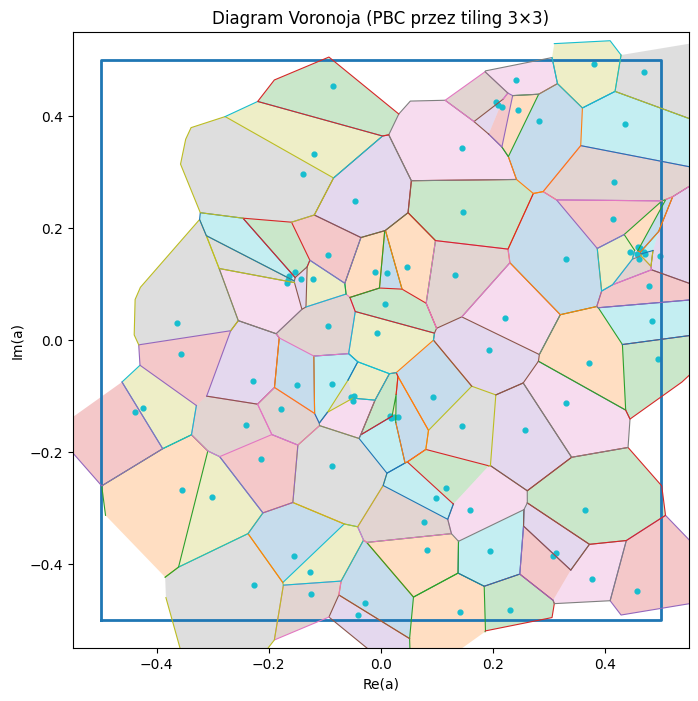

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi

# --- I/O ---
def load_points(csv_path: Path):
    df = pd.read_csv(csv_path)
    for col in ["a_re", "a_im", "r_norm"]:
        if col not in df.columns:
            raise ValueError(f"Brak kolumny '{col}' w CSV.")
    x = df["a_re"].to_numpy(float)
    y = df["a_im"].to_numpy(float)
    r = df["r_norm"].to_numpy(float)
    return x, y, r, df

def wrap_to_cell(u):
    return ((u + 0.5) % 1.0) - 0.5

def voronoi_pbc_3x3(x, y):
    x = wrap_to_cell(np.asarray(x, float))
    y = wrap_to_cell(np.asarray(y, float))
    N = len(x)

    shifts = [-1, 0, 1]
    pts = []
    base = []
    sh = []
    for sx in shifts:
        for sy in shifts:
            pts.append(np.column_stack([x + sx, y + sy]))
            base.append(np.arange(N))
            sh.append(np.column_stack([np.full(N, sx), np.full(N, sy)]))

    pts = np.vstack(pts)             # (9N, 2)
    base = np.concatenate(base)      # (9N,)
    sh = np.vstack(sh)               # (9N, 2)

    vor = Voronoi(pts)

    central_mask = (sh[:, 0] == 0) & (sh[:, 1] == 0)
    central_ids = np.where(central_mask)[0]   # indeksy w pts odpowiadające centralnym punktom
    return vor, pts, base, sh, central_ids

def plot_voronoi_cells(vor, pts, central_ids, title="Voronoi (PBC 3×3)"):
    fig, ax = plt.subplots(figsize=(8, 8))

    # obrys komórki centralnej
    ax.plot([-0.5, 0.5, 0.5, -0.5, -0.5], [-0.5, -0.5, 0.5, 0.5, -0.5], linewidth=2)

    # rysuj tylko regiony dla centralnych punktów
    for pid in central_ids:
        ridx = vor.point_region[pid]
        region = vor.regions[ridx]
        if -1 in region or len(region) == 0:
            # region nieskończony (rzadkie, ale możliwe przy brzegach 3×3)
            continue
        poly = vor.vertices[region]
        ax.fill(poly[:, 0], poly[:, 1], alpha=0.25, linewidth=0)
        ax.plot(poly[:, 0], poly[:, 1], linewidth=0.8)

    # punkty centralne
    ax.scatter(pts[central_ids, 0], pts[central_ids, 1], s=12)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-0.55, 0.55)
    ax.set_ylim(-0.55, 0.55)
    ax.set_title(title)
    ax.set_xlabel("Re(a)")
    ax.set_ylabel("Im(a)")
    plt.show()

# ---- uruchomienie ----
csv_path = Path("haadf_disks_bright.csv")   # <- zmień jeśli trzeba
x, y, r, _ = load_points(csv_path)

vor, pts, base, sh, central_ids = voronoi_pbc_3x3(x, y)
plot_voronoi_cells(vor, pts, central_ids, title="Diagram Voronoja (PBC przez tiling 3×3)")


Bibliografia:  
[1] Wykłady prof. W. Mitiuszew.